# EDA for Wine Quality

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./winequality-red.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [3]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## Univariate Analysis

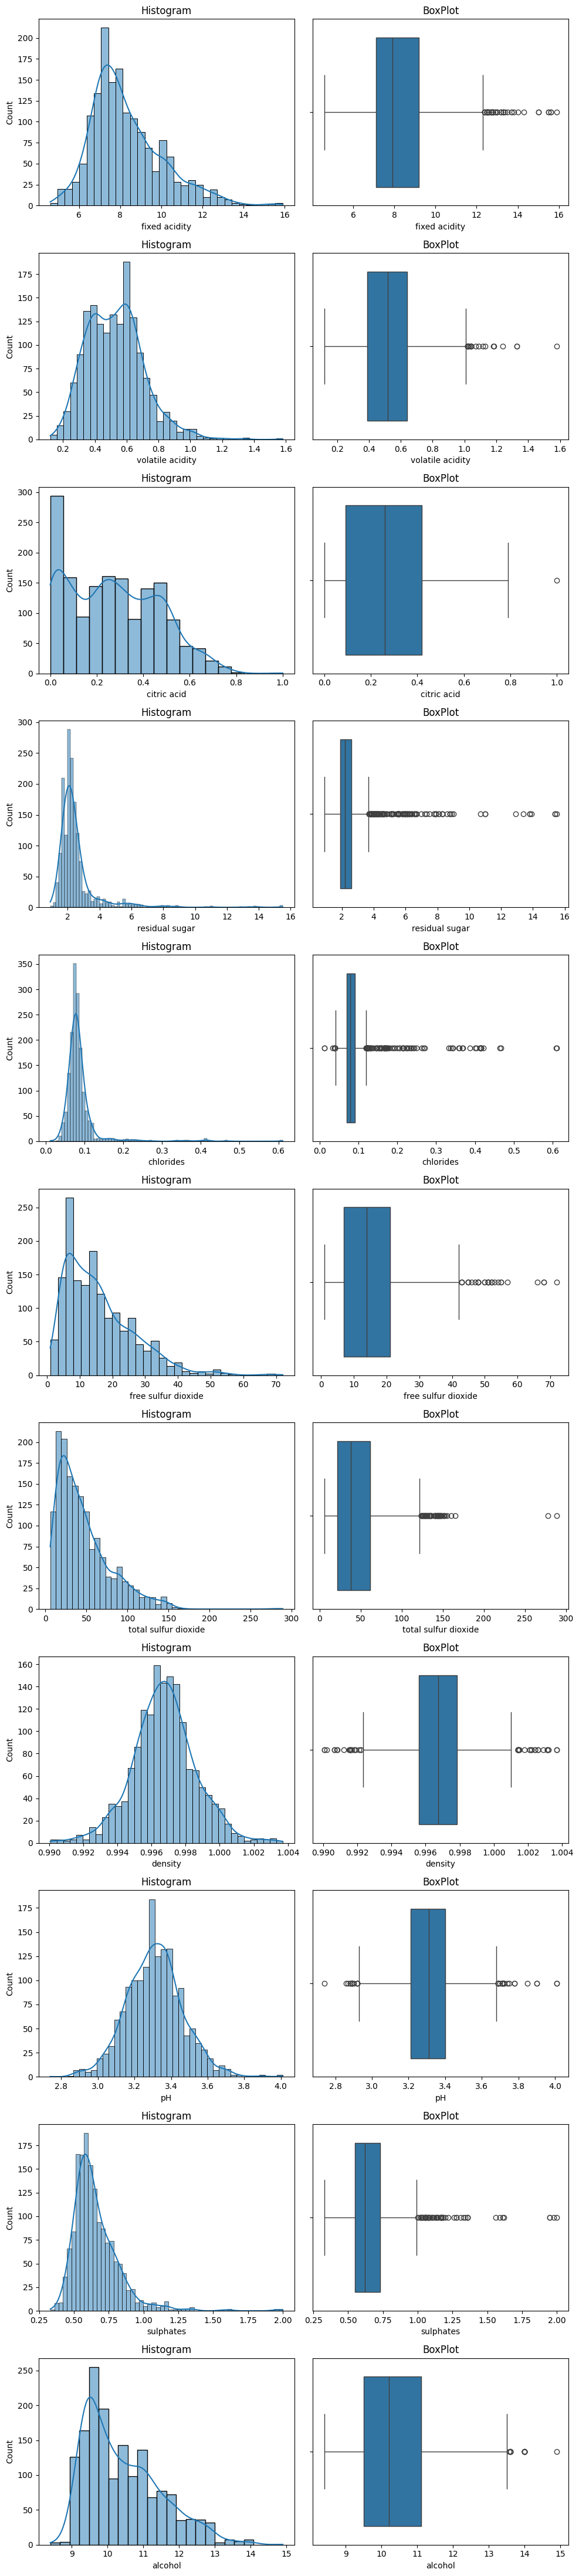

In [4]:
cols = df.select_dtypes("float64").columns

n = len(cols)

fig, axes = plt.subplots(n, 2, figsize=(10, 4*n))

for index, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[index, 0])
    axes[index, 0].set_title(f"Histogram")

    sns.boxplot(x=df[col], ax=axes[index, 1])
    axes[index, 1].set_title(f"BoxPlot")

plt.tight_layout()
plt.show()

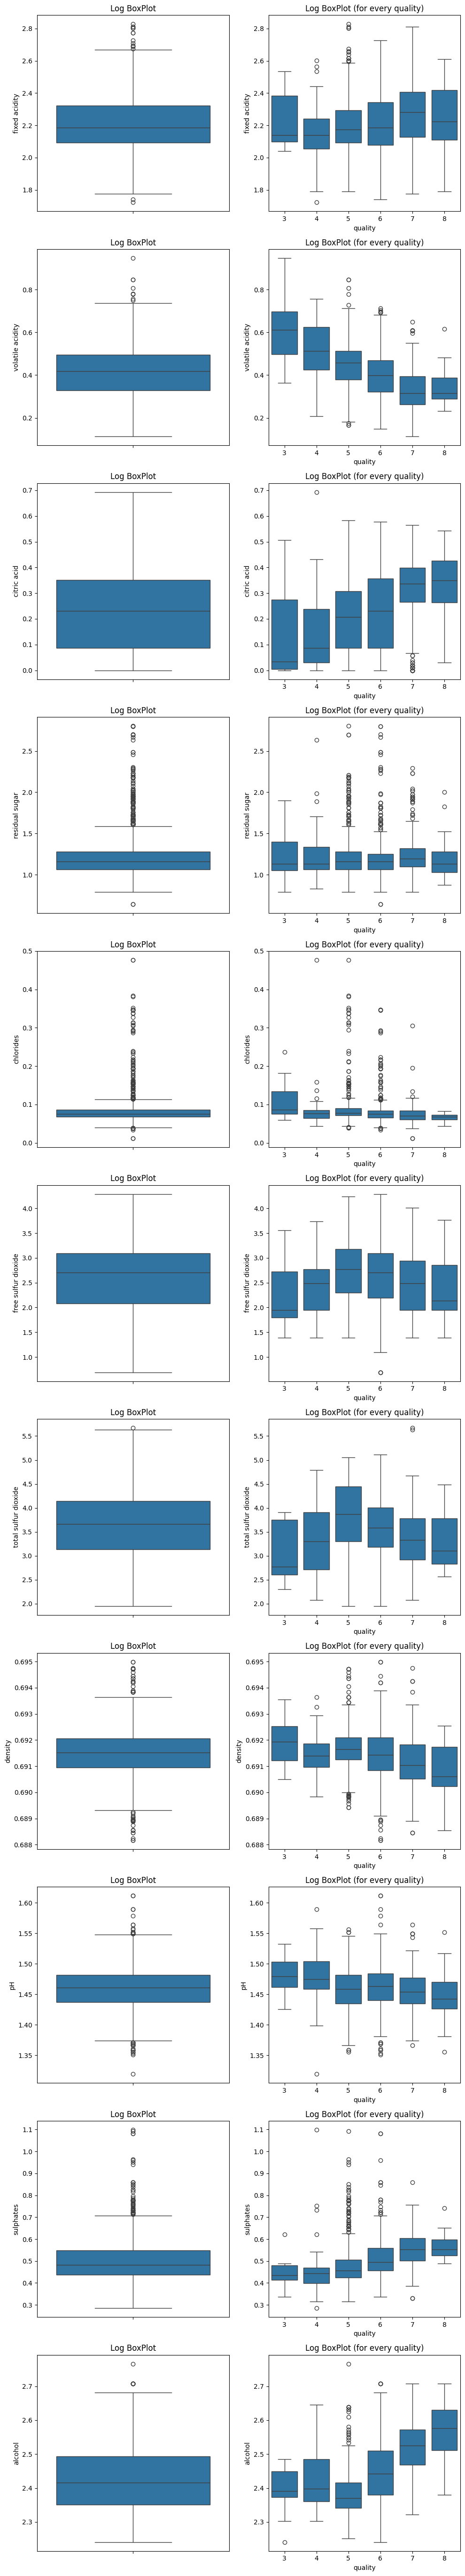

In [5]:
fig, axes = plt.subplots(n, 2, figsize=(10, 5*n))

for index, col in enumerate(cols):
    sns.boxplot(y=np.log1p(df[col]), ax=axes[index, 0])
    axes[index, 0].set_title(f"Log BoxPlot")

    sns.boxplot(x=df['quality'], y=np.log1p(df[col]), ax=axes[index, 1])
    axes[index, 1].set_title(f"Log BoxPlot (for every quality)")

plt.tight_layout()
plt.show()

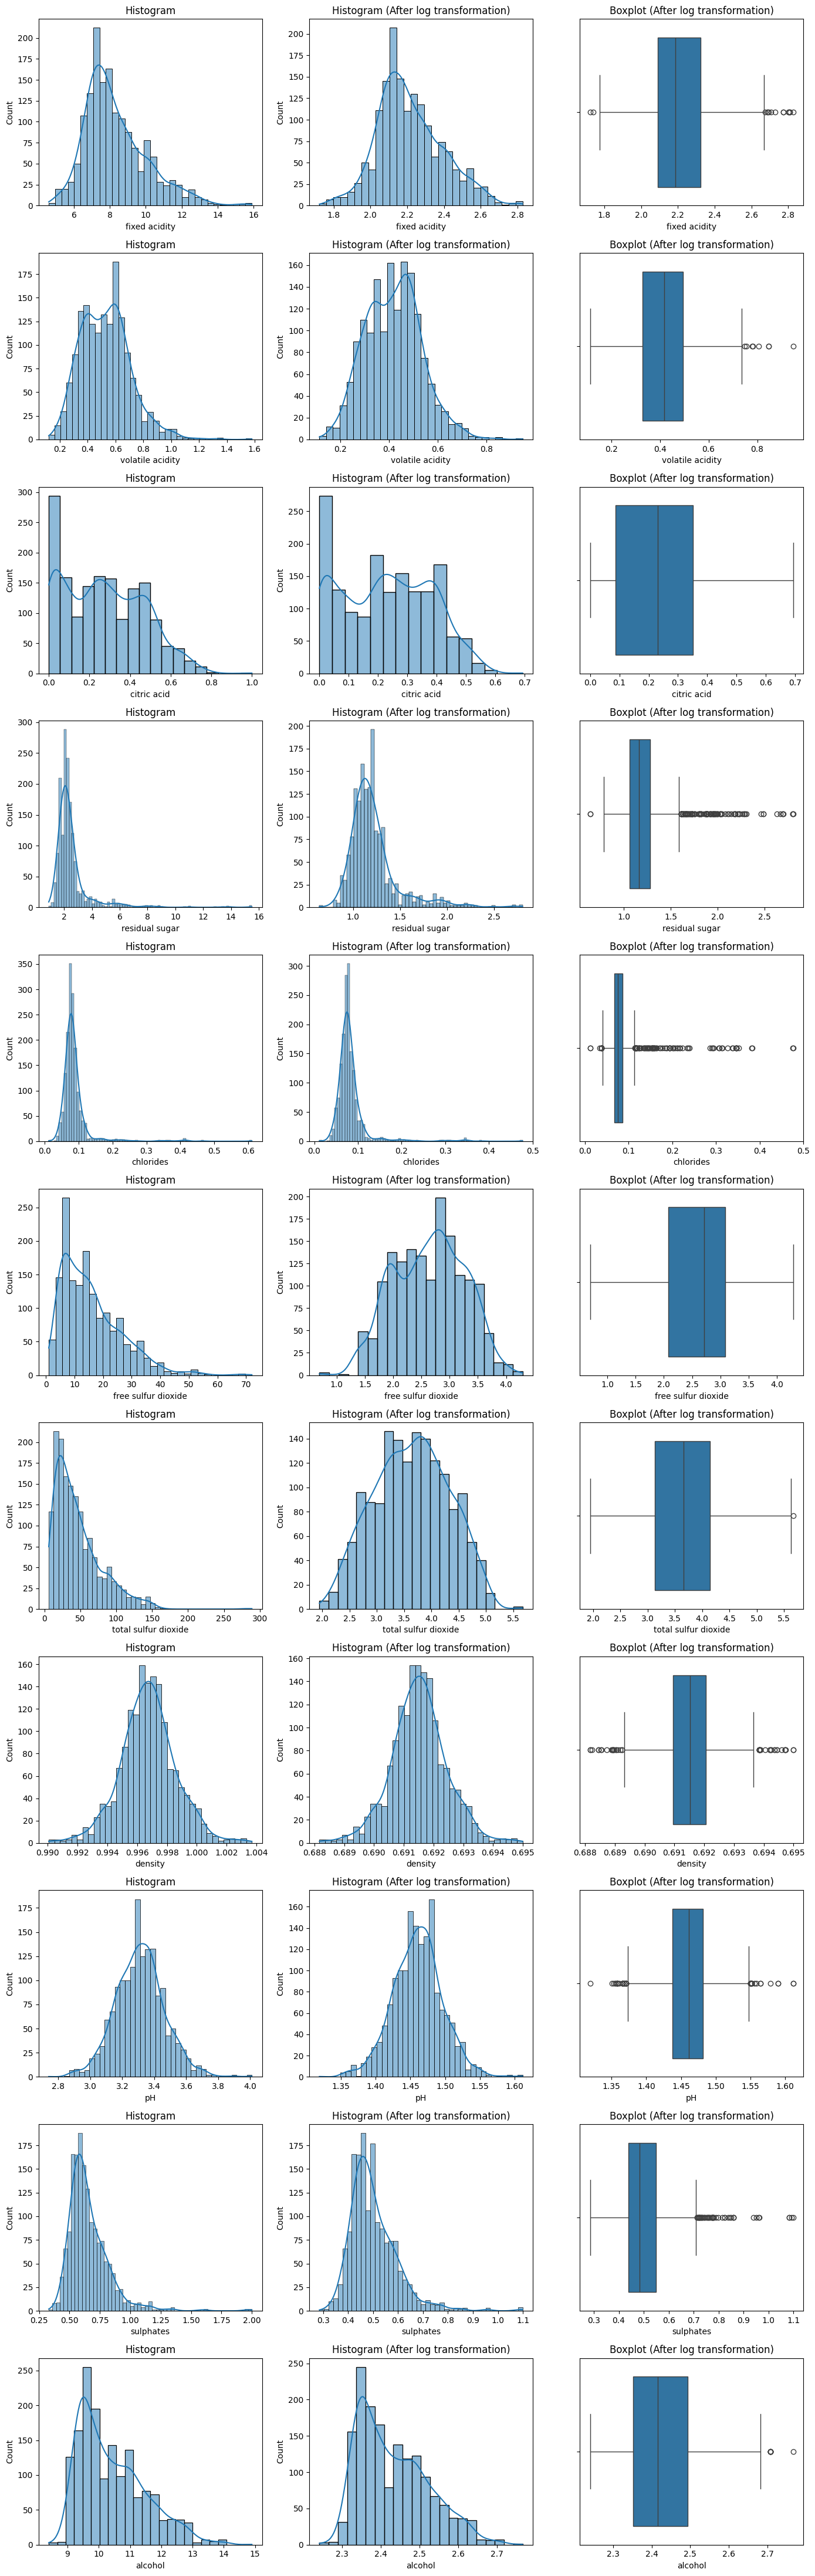

In [6]:
n = len(cols)

fig, axes = plt.subplots(n, 3, figsize=(14, 4*n))

for index, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[index, 0])
    axes[index, 0].set_title(f"Histogram")

    sns.histplot(np.log1p(df[col]), kde=True, ax=axes[index, 1])
    axes[index, 1].set_title(f"Histogram (After log transformation)")

    sns.boxplot(x=np.log1p(df[col]), ax=axes[index, 2])
    axes[index, 2].set_title(f"Boxplot (After log transformation)")

plt.tight_layout()
plt.show()

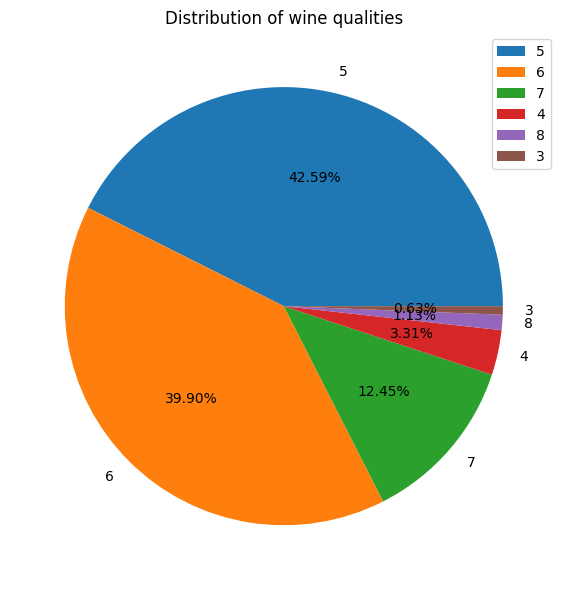

In [7]:
quality_types = df['quality'].value_counts().index
quality_values = df['quality'].value_counts().values

plt.figure(figsize=(10, 6))
plt.pie(quality_values, labels=quality_types, autopct="%.2f%%")
plt.title("Distribution of wine qualities")

plt.legend()
plt.tight_layout()
plt.show()

## Bivariate Analysis

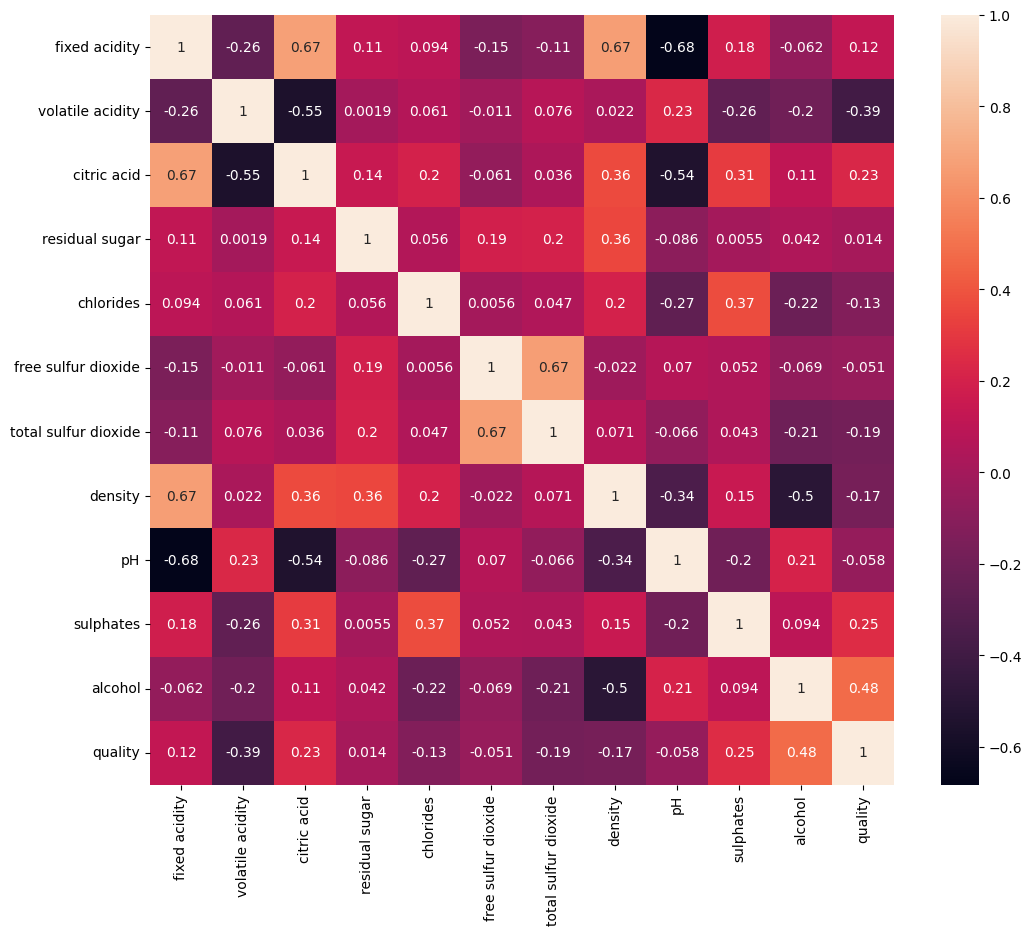

In [8]:
corr = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True)
plt.show()

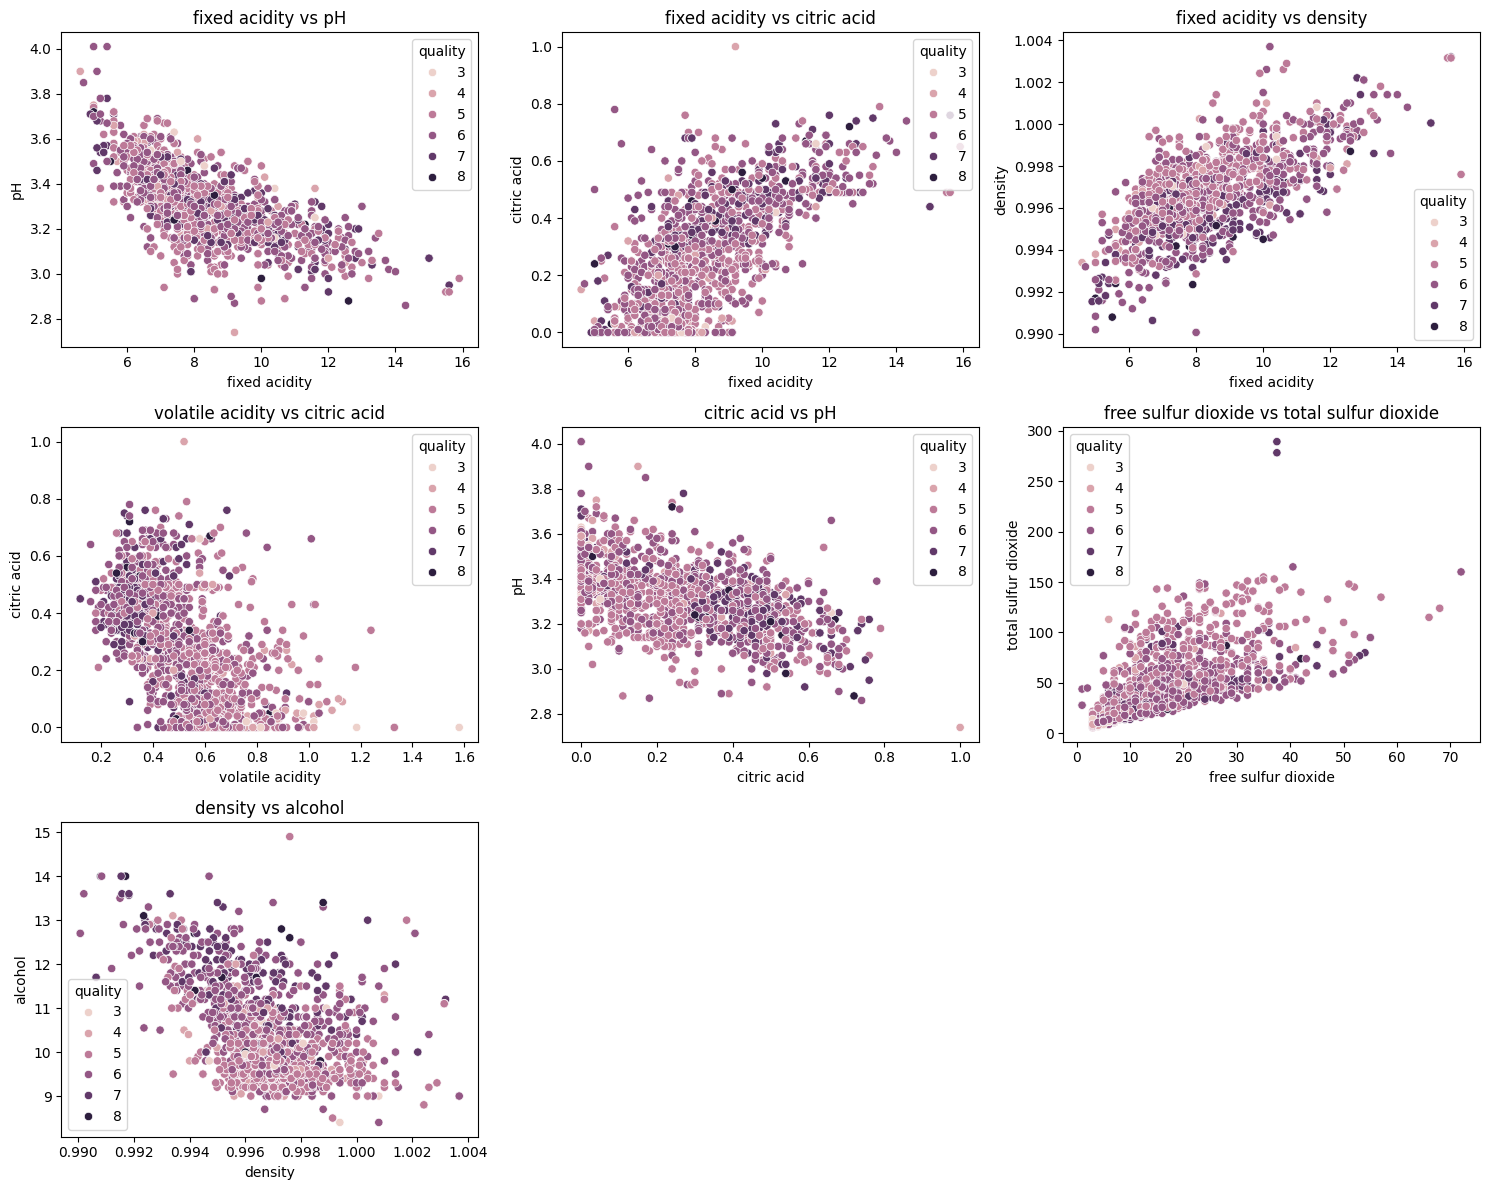

In [9]:
import math

pairs = [
    ("fixed acidity", "pH"), ("fixed acidity", "citric acid"), ("fixed acidity", "density"), ("volatile acidity", "citric acid"), ("citric acid", "pH"), ("free sulfur dioxide", "total sulfur dioxide"), ("density", "alcohol"), 
]
n_plots = len(pairs)

columns = 3
rows = math.ceil(n_plots / columns)

fig, axes = plt.subplots(rows, columns, figsize=(5*columns, 4*rows))
axes = axes.flatten()


for i, (f1, f2) in enumerate(pairs):
    sns.scatterplot(x=df[f1],y=df[f2],ax=axes[i], hue=df['quality'])
    axes[i].set_xlabel(f1)
    axes[i].set_ylabel(f2)
    axes[i].set_title(f"{f1} vs {f2}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Observations

- The dataset contains noticeable class imbalance:
  - Quality levels **5 (~42.6%)** and **6 (~39.9%)** dominate the dataset
  - Quality levels **3, 4, and 8** are significantly underrepresented
  - This imbalance may bias models toward predicting majority classes

- Several features such as **fixed acidity**, **volatile acidity**, **chlorides**, **residual sugar**,  
  **free sulfur dioxide**, **total sulfur dioxide**, **density**, **pH**, and **sulphates** show the presence of outliers  
  - Many of these outliers are likely valid extreme values rather than errors

- Log transformation improves the distribution of:
  - **free sulfur dioxide**
  - **total sulfur dioxide**  
  by reducing skewness and compressing extreme values

- **chlorides** and **residual sugar** are heavily right-skewed, while **sulphates** is moderately right-skewed  
  - This suggests the need for transformation

- From quality-based boxplots:
  - **alcohol**, **sulphates**, **citric acid**, and **volatile acidity** show clear trends across quality levels:
    - **alcohol**, **sulphates**, **citric acid** → increase with quality
    - **volatile acidity** → decreases with quality
  - These features exhibit relatively better separation and are strong predictors

- Features such as **residual sugar**, **pH**, **free sulfur dioxide**, and **total sulfur dioxide** show heavy overlap across quality levels  
  - These are weaker predictors of wine quality

- Some features (e.g., **density**, **fixed acidity**) show mild trends but with significant overlap  
  - These may act as moderate predictors

---

## Final Result

- Strong predictors of wine quality:
  - **alcohol**
  - **sulphates**
  - **citric acid**
  - **volatile acidity**

- Moderate predictors:
  - **density**
  - **fixed acidity**

- Weak predictors:
  - **residual sugar**
  - **pH**
  - **free sulfur dioxide**
  - **total sulfur dioxide**
  - **chlorides**
